# Técnicas e Instrumentación en Psicofisiología
Elaborado por el Mtro. Angel Jacobo para la Facultad de Medicina y Psicología, Universidad Autónoma de Baja California.

# Práctica 5: Procesamiento de Bioseñales, Electroencefalograma (EEG)

Durante esta práctica, el alumno ejercitará nuevamente la manipulación de contenedores con datos reales. Se familiarizará con algunos conceptos y técnicas básicas para el análisis de bioseñales, enfatizando aspectos más característicos del EEG, como el análisis espectral, potenciales evocados, potenciales relacionados a eventos y la estimación de origen.


##Funciones de apoyo
Ejecute estas celdas para preparar algunas características del ambiente que serán necesarias para la práctica

In [ ]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 22.0 MB/s eta 0:00:00
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.


In [ ]:
from mne.io import concatenate_raws, read_raw_edf
from mne.datasets import eegbci
subjects = [1]  # may vary
runs = [3]  # may vary
raw_fnames = eegbci.load_data(subjects, runs)
raws = [read_raw_edf(f, preload=True) for f in raw_fnames]
# concatenate runs from subject
raw = concatenate_raws(raws)
# make channel names follow standard conventions
eegbci.standardize(raw)


datos=[]
eventos=[[],[],[]]
for i in range(64):
    datos.append((raw[0][1][0:], raw[i][0][0][0:]))
for i in range(len(raw.annotations)):
  if raw.annotations[i]['description'] == 'T0':
    eventos[0].append(raw.annotations[i]['onset'])
  if raw.annotations[i]['description'] == 'T1':
    eventos[1].append(raw.annotations[i]['onset'])
  if raw.annotations[i]['description'] == 'T2':
    eventos[2].append(raw.annotations[i]['onset'])

Using default location ~/mne_data for EEGBCI...
Creating /root/mne_data


Do you want to set the path:
    /root/mne_data
as the default EEGBCI dataset path in the mne-python config [y]/n? y
Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 36s (2.5 MB)
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R03.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...


## Sección 1. Repaso: Manejo de Contenedores para Bioseñales

Recordará de prácticas anteriores que llamamos bioseñales a "aquellas variables físicas, registradas durante un periodo de tiempo, que nos ofrecen información respecto del estado de un sistema biológico."

De forma que su registro en Python cobra la forma de contenedores que guardan la información de mediciones individuales ordenadas en el tiempo. Para una adecuada interpretación del registro, es útil conocer las características del equipo utilizado.

#### Ejercicio 1.1

---


A continuación, puede ver una celda con código.
En ella puede ver un gráfico que representa los potenciales eléctricos registrados por un electrodo colocado sobre la piel cabelluda.

Ejecútela, observe el gráfico, y responda lo que se pide.

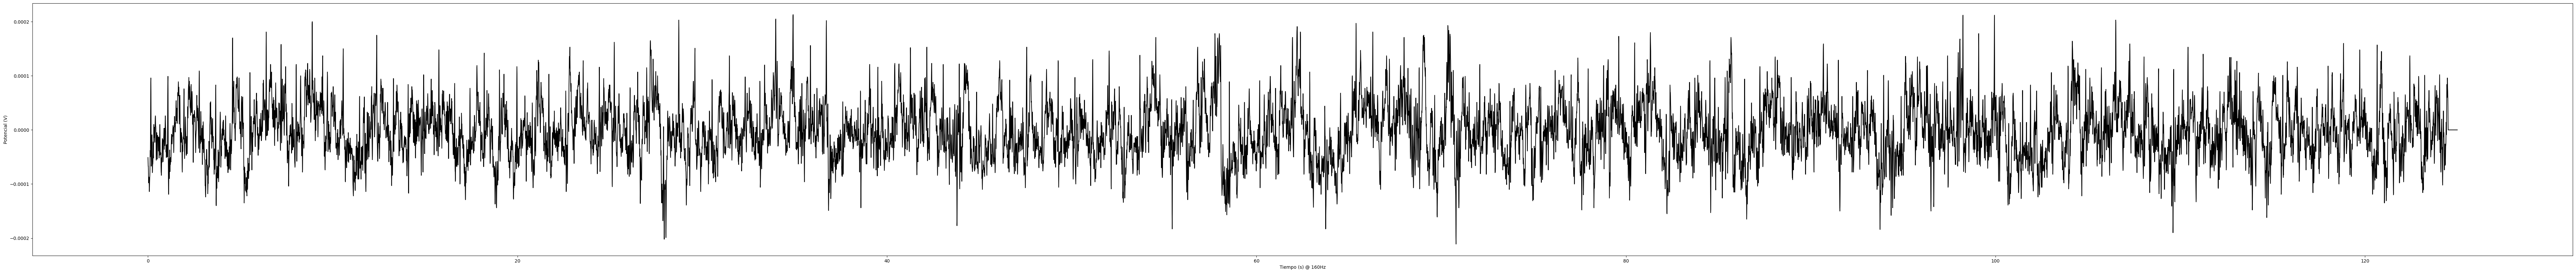

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(100,10))
plt.axes(xlabel= "Tiempo (s) @ 160Hz" , ylabel= "Potencial (V)")
plt.plot(datos[60][0], (datos[60][1]), color= "0" )

1.1.1 Responda: ¿Cuál es la duración aproximada, en segundos, del registro?

In [ ]:
#En apariencia, unos 124-125. Si se calcula directamente el tamaño del contenedor (20000) entre la frecuencia de muestreo (160) nos da exactamente 125s.

1.1.2 Responda: Si explora el tamaño de cada arreglo en 'datos' ¿Cuántos puntos de datos existen?

In [ ]:
#20000

1.1.3 Responda: ¿Qué significa que el registro haya sido tomado a 160Hz?

In [ ]:
#Que hay 160 mediciones por segundo

1.1.4 Responda: ¿Qué tipo de montaje se ha utilizado?

In [ ]:
# Referencial

### Ejemplo 1.1: Selección de ventanas

Reconocerá también el siguiente bloque de código. Es una forma sencilla de graficar los momentos de actividad específica del sujeto.

De la Práctica 2:

"Esta vez será importante considerar el acomodo de los mismos, que puede verificar en la liga siguiente: https://physionet.org/content/eegmmidb/1.0.0/64_channel_sharbrough.pdf

Añadiremos también la información de que al sujeto se le pide abrir y cerrar la mano correspondiente con una señal en la pantalla de una computadora. La celda siguiente grafica esta información:

- Las líneas verticales en amarillo representan el inicio de periodos de reposo,
- las líneas en azul representan el inicio de periodos de actividad con la mano izquierda,
- y las líneas en rojo representan el inicio de periodos de actividad con la mano derecha."



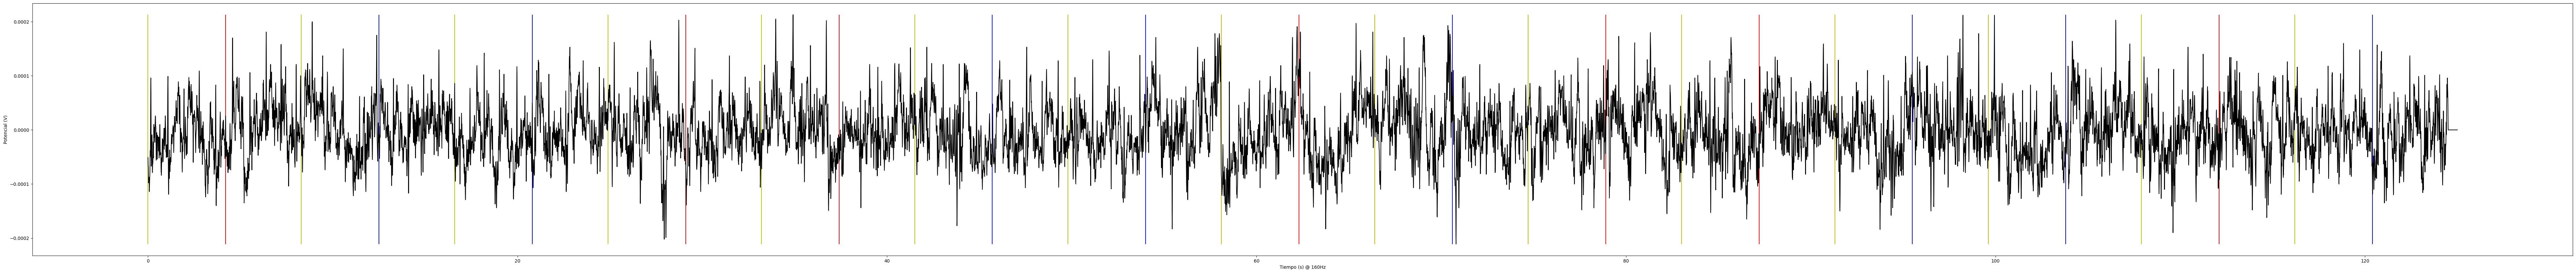

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

electrodo = 61

k = electrodo - 1
datamin= np.min(datos[k][1])
datamax= np.max(datos[k][1])
plt.figure(figsize= (100, 10))
plt.axes(xlabel= "Tiempo (s) @ 160Hz" , ylabel= "Potencial (V)")
plt.vlines(eventos[0], ymin=datamin, ymax=datamax, colors = 'y')
plt.vlines(eventos[1], ymin=datamin, ymax=datamax, colors = 'b')
plt.vlines(eventos[2], ymin=datamin, ymax=datamax, colors = 'r')

plt.plot(datos[k][0],datos[k][1], color='0')

Señalado lo anterior, verá que ahora podemos separar distintos momentos del registro en bloques de tiempo específicos. A estos bloques de tiempo les denominamos ventanas.

Esto significa que, si tomamos ventanas del mismo tiempo, tenemos la posibilidad de compararlas entre sí para obtener información que pueda repetirse en las mismas.

Similarmente, ya que cada bloque de actividad tiene una duración aproximada de 4 segundos, podemos ajustar nuestro tamaño de ventana a ese periodo multiplicado por la tasa de muestreo.

En este caso, 4 veces 160: 640 datos a partir del inicio de la ventana.

In [ ]:
## Un ejemplo de cómo puede utilizarse este valor:

largo_ventana = 640

ventanita_reposo = datos[k][1][0:largo_ventana]

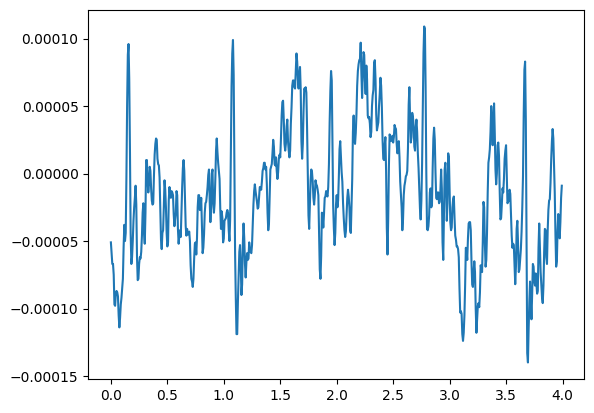

In [ ]:
plt.plot(datos[k][0][0:largo_ventana], ventanita_reposo)

#### Ejercicio 1.2

---
Extraiga por separado las ventanas correspondientes, y trate de encontrar la actividad eléctrica común calculando los promedios de la señal. Después conteste lo que se pide.


In [ ]:
# Objetivo de solución:
# Comparar los tiempos registrados en el objeto eventos
# Contra los tiempos verdaderos en el objeto datos
# Tomar un conjunto de mediciones de tamaño estandar desde
# la aparición de la señal de inicio


In [ ]:
print(eventos[0])

[np.float64(0.0), np.float64(8.3), np.float64(16.6), np.float64(24.9), np.float64(33.2), np.float64(41.5), np.float64(49.8), np.float64(58.1), np.float64(66.4), np.float64(74.7), np.float64(83.0), np.float64(91.3), np.float64(99.6), np.float64(107.9), np.float64(116.2)]


In [ ]:
print(datos[k][0][600])

3.75


In [ ]:
posicion 0, corresponde con evento 0

1.2.1 Responda: ¿Cómo puede saber las posiciones en el arreglo que representan el inicio de cada evento conductual?

In [ ]:
#Puede revisarse los datos que se encuentran en el contenedor de eventos
largo_ventana = 640

ventanita_reposo = datos[k][1][0:largo_ventana]
#Para reposo:
posiciones_evento_reposo = []
for elem in eventos[0]:
  posiciones_evento_reposo.append(int(np.where(datos[0][0] == elem)[0][0]))

#Extraer cada ventana de cuatro segundos de este electrodo
ventanas_datos_reposo = []
for i in posiciones_evento_reposo:
  ventanas_datos_reposo.append(datos[k][1][i:i+largo_ventana])
arreglo_ventanas_reposo = np.asarray(ventanas_datos_reposo)
promedio_ventanas_reposo = np.mean(arreglo_ventanas_reposo, axis=0)

################################################
####Para mano izquierda

posiciones_evento_izq = []
for elem in eventos[1]:
  posiciones_evento_izq.append(int(np.where(datos[0][0] == elem)[0][0]))

#Extraer cada ventana de cuatro segundos de este electrodo
ventanas_datos_izq = []
for i in posiciones_evento_izq:
  ventanas_datos_izq.append(datos[k][1][i:i+largo_ventana])
arreglo_ventanas_izq = np.asarray(ventanas_datos_izq)
promedio_ventanas_izq = np.mean(arreglo_ventanas_izq, axis=0)


######################################3
#Para mano derecha:

#Revisar los datos que se encuentran en el contenedor de eventos

posiciones_evento_der = []
for elem in eventos[2]:
  posiciones_evento_der.append(int(np.where(datos[0][0] == elem)[0][0]))

#Después, podemos extraer cada ventana de cuatro segundos de este electrodo
ventanas_datos_der = []
for i in posiciones_evento_der:
  ventanas_datos_der.append(datos[k][1][i:i+largo_ventana])
arreglo_ventanas_der = np.asarray(ventanas_datos_der)
promedio_ventanas_der = np.mean(arreglo_ventanas_der, axis=0)

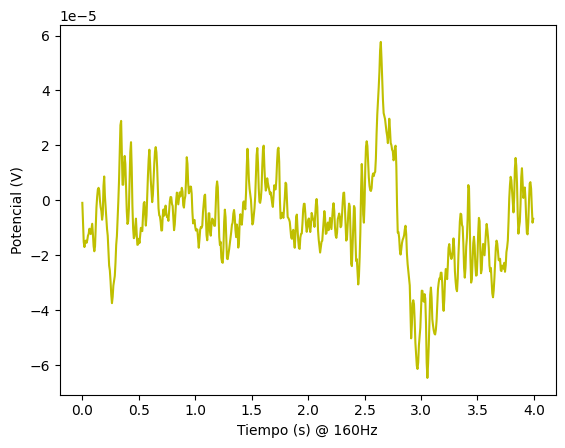

In [ ]:
plt.axes(xlabel= "Tiempo (s) @ 160Hz" , ylabel= "Potencial (V)")
plt.plot(datos[k][0][:640], promedio_ventanas_reposo, color='y')

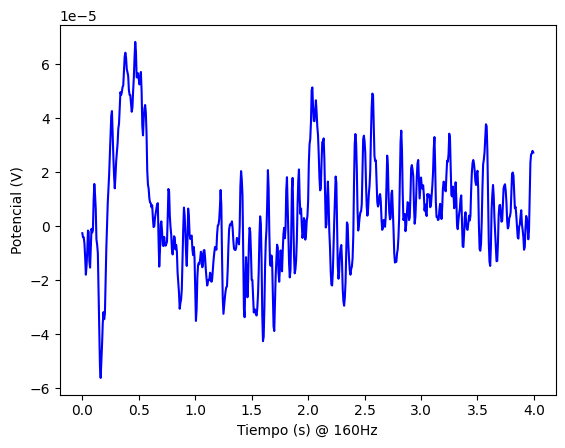

In [ ]:
plt.axes(xlabel= "Tiempo (s) @ 160Hz" , ylabel= "Potencial (V)")
plt.plot(datos[k][0][:640], promedio_ventanas_izq, color='b')

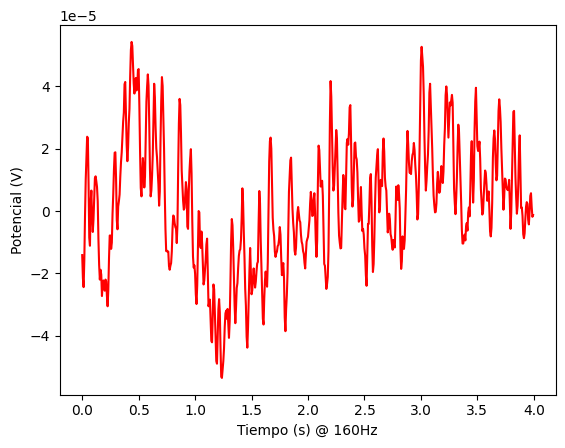

In [ ]:
plt.axes(xlabel= "Tiempo (s) @ 160Hz" , ylabel= "Potencial (V)")
plt.plot(datos[k][0][:640], promedio_ventanas_der, color='r')

1.2.2 Responda: ¿Qué pasa si promedia los valores de las ventanas del mismo tipo?"

1.2.3 Responda: ¿Qué pasa si promedia los valores de las ventanas del mismo tipo cuando provienen de distintos electrodos?

In [ ]:
#Electrodos de interés lado derecho
motor_der = [5, 6, 7, 40, 12, 13, 14, 42]
promedios_electrodos_der=[]
for k in motor_der:
  ventanas_datos_der = []
  for i in posiciones_evento_der:
    ventanas_datos_der.append(datos[k][1][i:i+largo_ventana])
  arreglo_ventanas_der = np.asarray(ventanas_datos_der)
  promedio_ventanas_der = np.mean(arreglo_ventanas_der, axis=0)
  promedios_electrodos_der.append(promedio_ventanas_der)
arreglo_electrodos_der = np.asarray(promedios_electrodos_der)
grand_average_der = np.mean(arreglo_electrodos_der, axis=0)




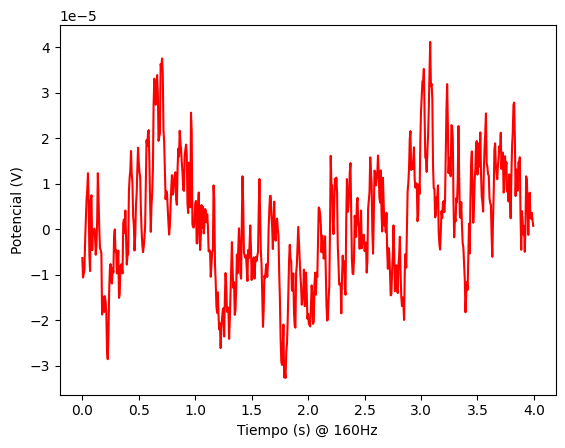

In [ ]:
plt.axes(xlabel= "Tiempo (s) @ 160Hz" , ylabel= "Potencial (V)")
plt.plot(datos[k][0][:640], grand_average_der, color='r')

In [ ]:
#Electrodos de interés lado derecho, movimiento izq
motor_der = [5, 6, 7, 40, 12, 13, 14, 42]
promedios_electrodos_izq=[]
for k in motor_der:
  ventanas_datos_izq = []
  for i in posiciones_evento_izq:
    ventanas_datos_izq.append(datos[k][1][i:i+largo_ventana])
  arreglo_ventanas_izq = np.asarray(ventanas_datos_izq)
  promedio_ventanas_izq = np.mean(arreglo_ventanas_izq, axis=0)
  promedios_electrodos_izq.append(promedio_ventanas_izq)
arreglo_electrodos_izq = np.asarray(promedios_electrodos_izq)
grand_average_izq = np.mean(arreglo_electrodos_izq, axis=0)


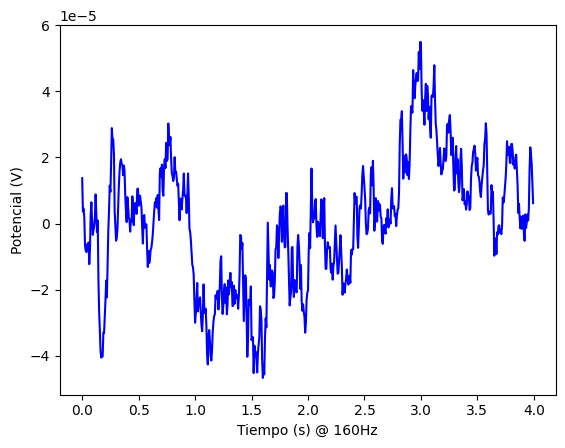

In [ ]:
plt.axes(xlabel= "Tiempo (s) @ 160Hz" , ylabel= "Potencial (V)")
plt.plot(datos[k][0][:640], grand_average_izq, color='b')